# Linear Models Modeling

In [19]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import sys
from pathlib import Path

pd.set_option("display.max_columns", 500)

sys.path.append(str(Path().cwd().parent.resolve()))

import preprocessing.features as features

builder = features.FeatureBuilder()

df = pd.read_csv(features.DATASET_PATH)

df_copy = builder.get_df(df)

df_copy.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(74111, 27)

# Baseline Model. Linear Regression

This section establishes a baseline performance using a standard **Linear Regression** model without hyperparameters tuning. The goal is to obtain a reliable reference point before evaluating more advanced linear models such as Ridge, Lasso and ElasticNet.

For this baseline experiment, the dataset contains only engineered features, created during the feature engineering stage. Additional features sets, including **amenities** and **description sentence embeddings**, are intentionally excluded. Their predictive value will be evaluated separately in dedicated experiments after selecting the most suitable linear model.

The **zipcode** feature is also excluded from this baseline. Encoding this variable with One-Hot-Encoding would introduce more than 700 additional sparse features, substantially increasing the dimensionality of the dataset. Instead the model relies on other geographical features - **city**, **neighbourhood** and **distance_to_listing_center** - which are expected to capture the majority of spatial information, while keeping the feature space compact and interpratable.

Finally, the trained model will be evaluated on the test set using standard regression metrics to establish the baseline performance for subsequent experiments.

In [20]:
df_copy = builder.get_df(df)

X = df_copy.drop(columns=['log_price'])
y = df_copy['log_price']

X = X.drop(columns=['zipcode'])

X.shape, y.shape

((74111, 25), (74111,))

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, y_train.shape

((59288, 25), (59288,))

In [22]:
import preprocessing.linear_preprocessor as preprocessor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

cat_features = X_train.select_dtypes(include=['object', 'string']).columns
num_features = X_train.select_dtypes(include=['number']).columns

linear_preprocessor = preprocessor.create_linear_preprocessor(num_features=num_features, cat_features=cat_features)

linear_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred_test_log = linear_pipeline.predict(X_test)
y_pred_train_log = linear_pipeline.predict(X_train)

y_pred_test = np.exp(y_pred_test_log)
y_pred_train = np.exp(y_pred_train_log)

test_MAE = mean_absolute_error(np.exp(y_test), y_pred_test)
train_MAE = mean_absolute_error(np.exp(y_train), y_pred_train)

test_RMSE = root_mean_squared_error(np.exp(y_test), y_pred_test)
train_RMSE = root_mean_squared_error(np.exp(y_train), y_pred_train)

test_r2 = r2_score(y_test, y_pred_test_log)
train_r2 = r2_score(y_train, y_pred_train_log)

print(f"Test MAE: {test_MAE:.2f} $ | Train MAE: {train_MAE:.2f} $")
print(f"Test RMSE: {test_RMSE:.2f} $ | Train RMSE: {train_RMSE:.2f} $")
print(f"Test R2 Score: {test_r2:.2f} | Train R2 Score: {train_r2:.2f}")

Test MAE: 54.58 $ | Train MAE: 53.61 $
Test RMSE: 123.72 $ | Train RMSE: 120.54 $
Test R2 Score: 0.66 | Train R2 Score: 0.66


In [23]:
results_df = pd.DataFrame(
    columns=["MAE", "RMSE", "R2"]
)

results_df.loc['Linear Regression'] = [
    round(test_MAE, 2),
    round(test_RMSE, 2),
    round(test_r2, 2)
]

results_df

,MAE,RMSE,R2
Linear Regression,54.58,123.72,0.66


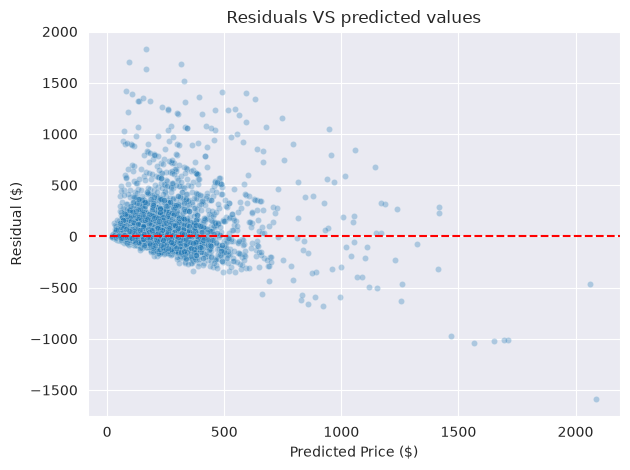

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = np.exp(y_test) - y_pred_test

sns.set_style("darkgrid")

sns.scatterplot(
    x=y_pred_test,
    y=residuals,
    alpha=0.3,
    s=20
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")
plt.title("Residuals VS predicted values")

plt.tight_layout()
plt.show()

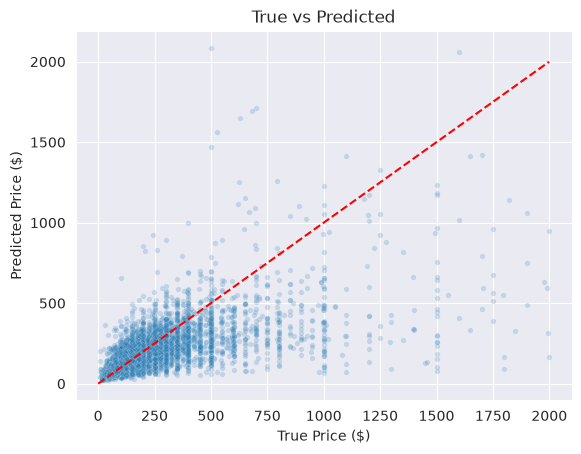

In [25]:
sns.scatterplot(
    x=np.exp(y_test),
    y=y_pred_test,
    alpha=0.2,
    s=15
)

plt.plot(
    [0, np.exp(y_test).max()],
    [0, np.exp(y_test).max()],
    color="red",
    linestyle="--"
)

plt.xlabel("True Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("True vs Predicted")

plt.show()

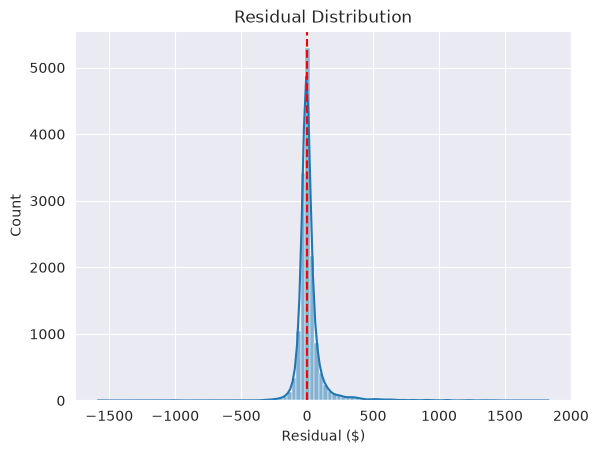

In [26]:
sns.histplot(
    residuals,
    bins=100,
    kde=True
)

plt.axvline(0, color='red', linestyle='--')

plt.xlabel("Residual ($)")
plt.title("Residual Distribution")

plt.show()

## Baseline Model. Linear Regression Conclusion

Linear Regression was used as the baseline model to establish a reference point for future experiments. The model acheived an R2 score of **0.66** on both the training and test sets, inddicating good generalization and no evidence of overfitting. The small difference between train and test metrics suggests that the preprocessing pipeline and feature set produce stable results.

The model achieved **Mean Absolute Error (MAE) of approximately \$55**, meaning that, on average, predicted listing prices differ from the true prices by about \$55. The **Root Mean Squared Error (RMSE) of approximately \$124** is noticeably higher than the MAE, indicating the presence of several large prediction errors, primarily for expensive listings.

Residual Analysis showed no clear non-linear pattern, suggesting that the model successfully caaptures the main linear relationships in the data. However, the residual variance increases for higher predicted prices, indicating that expensive listings are inherently more difficult to predict. The residual distribution is approximately symmetric around zero, which suggests that the model does not systematically overestimate or underestimate listing prices.

The *True VS Predicted* plot further revealed that the model performs well for the majority low and mid priced listings but consistently underestimates higher priced properties.

Overall, Linear Regression provides a strong and interpetable baseline for this project.

# Evaluation Metrics

Based on the baseline **Linear Regression** Analysis, **RMSE** was selected as the primary optimization metric for model selection and hyperparameter tuning. The baseline model results indicated that the model performs reasonably well for the majority of listings but struggles with high-priced properties, where prediction errors become susbtantially larger. Since RMSE penalizes large errors more heavily than MAE, it is the most appropriate metric for evaluating improvements in this project.

The following experiments are aimed to reduce these large prediction errors through several hypotheses, including:

* Evaluating regularized linear models (**Ridge**, **Lasso** and **ElasticNet**);
* Enriching the feature space with additional information (**amenities**, **description embeddings**);
* Exploring more expensive non-linear models, such as **RandomForest**, **XGBoost** and **CatBoost**;  

# Regularized Linear Models


## Ridge Regression

In this section we evaluate **Ridge Regression**, a linear model with **L2 Regulization**, and compare its performance with the baseline **Linear Regression**. We use **GridSearchCV** to find the optimal regularization strength (`alpha`) and assess whether L2 regularization improves the model's generalization performance. on the Airbnb price prediction task.

In [27]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

ridge_grid.best_params_

{'model__alpha': 1}

In [28]:
y_pred_test_log = ridge_grid.predict(X_test)
y_pred_train_log = ridge_grid.predict(X_train)

y_pred_test = np.exp(y_pred_test_log)
y_pred_train = np.exp(y_pred_train_log)

test_MAE = mean_absolute_error(np.exp(y_test), y_pred_test)
train_MAE = mean_absolute_error(np.exp(y_train), y_pred_train)

test_RMSE = root_mean_squared_error(np.exp(y_test), y_pred_test)
train_RMSE = root_mean_squared_error(np.exp(y_train), y_pred_train)

test_R2 = r2_score(y_test, y_pred_test_log)
train_R2 = r2_score(y_train, y_pred_train_log)

print(f"Ridge Test MAE: {test_MAE:.2f}$ | Ridge Train MAE: {train_MAE:.2f}$")
print(f"Ridge Test RMSE: {test_RMSE:.2f}$ | Ridge Train RMSE: {train_RMSE:.2f}$")
print(f"Ridge Test R2 Score: {test_R2:.2f} | Ridge Train R2 Score: {train_R2:.2f}")

Ridge Test MAE: 54.58$ | Ridge Train MAE: 53.61$
Ridge Test RMSE: 123.75$ | Ridge Train RMSE: 120.55$
Ridge Test R2 Score: 0.66 | Ridge Train R2 Score: 0.66


In [29]:
results_df.loc["Ridge"] = [
    round(test_MAE, 2),
    round(test_RMSE, 2),
    round(test_R2, 2)
]

results_df

,MAE,RMSE,R2
Linear Regression,54.58,123.72,0.66
Ridge,54.58,123.75,0.66


### Reidge Regression Conclusion

Ridge Regression achieved virtually identical to the baseline Linear Regression model accross all evaluated metrics. The best hyperparameter (`alpha = 1`) did not lead to any meaningful improvement in MAE, RMSE or R2. This suggests that the baseline linear model is already well-generalized and does not suffer from significant overfitting or unstable coefficients. Therefore, adding L2 regularization provides little benefit for this dataset, indicating that the primary limitation is likely the linear nature of the model rather than the absence of regularization.

## Lasso Regression

In this section, we evaluate **Lasso Regression**, a linear model with **L1 regularization**, and compare its performance with both baseline **Linear Regression** and **Ridge Regression** models. Unlike Ridge, Lasso is capable of shrinking some feature coefficients exactly to zero, effectively performing automatic feature selection. We use **GridSearchCV** to identify the optimal regularization strength (`alpha`) and investigate whether L1 regularization can improve predictive performance while producing a simpler and more interpretable model.

In [31]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Lasso(max_iter=10000))
])

lasso_params = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid=lasso_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

lasso_grid.best_params_

{'model__alpha': 0.0001}

In [33]:
y_pred_test_log = lasso_grid.predict(X_test)
y_pred_train_log = lasso_grid.predict(X_train)

y_pred_test = np.exp(y_pred_test_log)
y_pred_train = np.exp(y_pred_train_log)

test_MAE = mean_absolute_error(np.exp(y_test), y_pred_test)
train_MAE = mean_absolute_error(np.exp(y_train), y_pred_train)

test_RMSE = root_mean_squared_error(np.exp(y_test), y_pred_test)
train_RMSE = root_mean_squared_error(np.exp(y_train), y_pred_train)

test_R2 = r2_score(y_test, y_pred_test_log)
train_R2 = r2_score(y_train, y_pred_train_log)

print(f"Lasso Test MAE: {test_MAE:.2f}$ | Lasso Train MAE: {train_MAE:.2f}$")
print(f"Lasso Test RMSE: {test_RMSE:.2f}$ | Lasso Train RMSE: {train_RMSE:.2f}$")
print(f"Lasso Test R2 Score: {test_R2:.2f} | Lasso Train R2 Score: {train_R2:.2f}")

Lasso Test MAE: 54.75$ | Lasso Train MAE: 53.74$
Lasso Test RMSE: 124.32$ | Lasso Train RMSE: 120.94$
Lasso Test R2 Score: 0.66 | Lasso Train R2 Score: 0.66


In [35]:
results_df.loc['Lasso'] = [
    round(test_MAE, 2),
    round(test_RMSE, 2),
    round(test_R2, 2)
]

results_df

,MAE,RMSE,R2
Linear Regression,54.58,123.72,0.66
Ridge,54.58,123.75,0.66
Lasso,54.75,124.32,0.66


In [38]:
best_lasso = lasso_grid.best_estimator_

coefficients = best_lasso.named_steps['model'].coef_
feature_names = best_lasso.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

(coef_df['Coefficient'] == 0).sum()

np.int64(44)

In [40]:
coef_df.shape

(266, 2)

In [39]:
coef_df[coef_df["Coefficient"] == 0]["Feature"].tolist()

['cat__property_type_Cabin',
 'cat__property_type_Castle',
 'cat__property_type_Guest suite',
 'cat__property_type_Serviced apartment',
 'cat__property_type_Tent',
 'cat__property_type_Townhouse',
 'cat__property_type_Vacation home',
 'cat__room_type_Private room',
 'cat__cancellation_policy_flexible',
 'cat__neighbourhood_Alamo Square',
 'cat__neighbourhood_Altadena',
 'cat__neighbourhood_Arcadia',
 'cat__neighbourhood_Cleveland Park',
 'cat__neighbourhood_Cole Valley',
 'cat__neighbourhood_Del Rey',
 'cat__neighbourhood_Duboce Triangle',
 'cat__neighbourhood_Edgewater',
 'cat__neighbourhood_Encino',
 'cat__neighbourhood_Fenway/Kenmore',
 'cat__neighbourhood_Glen Park',
 'cat__neighbourhood_Gowanus',
 'cat__neighbourhood_Haight-Ashbury',
 'cat__neighbourhood_Hayes Valley',
 'cat__neighbourhood_Kalorama',
 'cat__neighbourhood_Kingman Park',
 'cat__neighbourhood_Long Island City',
 'cat__neighbourhood_Los Feliz',
 'cat__neighbourhood_Mar Vista',
 'cat__neighbourhood_Morningside Heights'

### Lasso Regression Conclusion

Lasso Regression selected the smallest tested regularization strength (`alpha = 0.0001`), indicating that only a minimal amount of L1 regularization was beneficial for this dataset. Despite the weak regularization, the model assigned **exactly zero coefficients to 44 out of 266**, producing a sparser linear model. The predictive performance, however, was slightly worse than both the Linear Regression and Ridge Regression models, suggesting that the sparse representation did not improve generalization. 

An inspection of the learned coefficients showed that nearly all zero-valued coefficients correspond to features created by **One-Hot-Encoding**, while only one engineered numerical feature (`host_since_year`) received a zero coefficient. This is likely because its information overlaps with the more informative `host_age_days` feature, making it largely redundant. Overall Lasso successfully identified features with little or redundant contribution, but this sparsity came at the cost of small decrease in predictive performance.

## ElasticNet Regression